In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import shap

In [11]:
train_df = pd.read_csv("data/train.csv")
TARGET = "target"

X = train_df.drop(columns=[TARGET, "ID"])
y = train_df[TARGET]
y_log = np.log1p(y)

In [12]:
#fit XGBoost as primary model
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)

xgb_model.fit(X, y_log)

#fit LightGBM as secondary model
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X, y_log)

#fit randomforest as comparison
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.111245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 163400
[LightGBM] [Info] Number of data points in the train set: 4459, number of used features: 3441
[LightGBM] [Info] Start training from score 14.490239


RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

🟢 1. CORE FEATURES (high agreement)

Important in:

XGBoost
LightGBM
Random Forest

👉 Interpretation:

true signal carriers

These are your safest features

🟡 2. BOOSTING-ONLY FEATURES

Important in:

XGBoost + LightGBM
NOT Random Forest

👉 Interpretation:

nonlinear / interaction-heavy signals

These are often:

sparse triggers
threshold effects
event-like signals
🔵 3. RF-ONLY FEATURES

Important in:

Random Forest only

👉 Interpretation:

stable averages or weak smoothing signals

Often:

redundant
or weak standalone predictors
🔴 4. NOISE CANDIDATES

Low importance in all models

👉 Interpretation:

safe candidates for removal (after validation)

In [23]:
X_sample = X.sample(2000, random_state=42)

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = xgb_explainer.shap_values(X_sample)

lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap = lgb_explainer.shap_values(X_sample)

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap = rf_explainer.shap_values(X_sample)

xgb_imp = np.abs(xgb_shap).mean(axis=0)
lgb_imp = np.abs(lgb_shap).mean(axis=0)
rf_imp = np.abs(rf_shap).mean(axis=0)

xgb_med = consensus_df["xgb_shap"].median()
lgb_med = consensus_df["lgb_shap"].median()
rf_med = consensus_df["rf_shap"].median()

We extract:

per-feature contribution distributions for each model

This is the raw “signal interpretation layer”.

SHAP values per row are noisy.

We need:

global feature strength signal

This converts:

per-row explanations → dataset-level importance

In [19]:
consensus_df = pd.DataFrame({
    "feature": X_sample.columns,
    "xgb_shap": xgb_imp,
    "lgb_shap": lgb_imp,
    "rf_shap": rf_imp
})

Now every feature has:

3 independent “importance opinions”

This is your feature voting system.

In [20]:
for col in ["xgb_shap", "lgb_shap", "rf_shap"]:
    consensus_df[col] = consensus_df[col] / consensus_df[col].sum()

Without this:

XGBoost dominates numerically
comparisons are meaningless

Now we compare relative importance, not raw magnitude.

In [21]:
consensus_df["mean_importance"] = consensus_df[
    ["xgb_shap", "lgb_shap", "rf_shap"]
].mean(axis=1)

consensus_df["std_importance"] = consensus_df[
    ["xgb_shap", "lgb_shap", "rf_shap"]
].std(axis=1)

consensus_df["consensus_score"] = (
    consensus_df["mean_importance"] / (consensus_df["std_importance"] + 1e-9)
)

| Metric          | Meaning                          |
| --------------- | -------------------------------- |
| mean importance | how important feature is overall |
| std importance  | disagreement between models      |
| consensus score | stability-adjusted importance    |


In [24]:
q_high = consensus_df["mean_importance"].quantile(0.80)
q_low = consensus_df["mean_importance"].quantile(0.50)

def classify(row):
    models = [
        row["xgb_shap"] > xgb_med,
        row["lgb_shap"] > lgb_med,
        row["rf_shap"] > rf_med
    ]
    
    count = sum(models)

    if count == 3:
        return "CORE_FEATURE"
    elif count == 2:
        return "BOOSTING_FEATURE"
    elif count == 1:
        return "MODEL_SPECIFIC"
    else:
        return "NOISE"

consensus_df["category"] = consensus_df.apply(classify, axis=1)

In [30]:
consensus_df.sort_values("consensus_score", ascending=False).head(10)
consensus_df["category"].value_counts()

category
NOISE               1782
CORE_FEATURE        1533
MODEL_SPECIFIC       896
BOOSTING_FEATURE     780
Name: count, dtype: int64

## 🟢 CORE FEATURES ##
- stable across all models
- true predictive signal

## 🟡 BOOSTING FEATURES ##
- only trees see them
- likely interactions / thresholds

## 🔵 MODEL-SPECIFIC FEATURES ##
- unstable signals
- may reflect model bias

## 🔴 NOISE ##
- safe removal candidates (later!)

## 🟦 FINAL FEATURE SET - STEP 1 — Feature agreement heatmap

This shows how aligned the models are per feature.

In [41]:
consensus_df["stability"] = 1 / (consensus_df["std_importance"] + 1e-9)

importance_threshold = consensus_df["mean_importance"].quantile(0.50)
stability_threshold = consensus_df["stability"].quantile(0.50)

prune_candidates = consensus_df[
    (consensus_df["mean_importance"] < importance_threshold) &
    (consensus_df["stability"] < stability_threshold)
]["feature"]

len(prune_candidates), prune_candidates.head(20)

(52,
 51      151d318cd
 52      ab0cddb90
 56      a8c320153
 136     60cb16e88
 143     665493ecc
 205     52695ed4a
 362     bc2eb559b
 457     a0129f413
 473     1d1cafe32
 481     2baea1172
 512     8677d6620
 518     b70c62d47
 601     b062e1a6f
 662     cc02b385f
 691     1a67a2101
 740     63f291ac1
 966     4d2ca4d52
 1110    cc93bdf83
 1246    d208491c8
 1326    0f6386200
 Name: feature, dtype: object)

# 🧠 What this means

You are now removing features that are:

- weak signal
- inconsistent across models

# 👉 these are almost always:

- sparse noise columns
- accidental splits
- redundant encodings

In [42]:
final_features = consensus_df[
    consensus_df["category"].isin(["CORE_FEATURE", "BOOSTING_FEATURE"])
]["feature"]

X_final = X[final_features].copy()

In [78]:
X_final.columns

Index(['34b15f335', '20aa07010', 'dc5a8f1d8', '11d86fa6a', '77c9823f2',
       '4681de4fd', 'adf119b9a', '96f83a237', 'b8a716ebf', 'f3b9c0b95',
       ...
       '8d8bffbae', '2a1f6c7f9', '9437d8b64', '5831f4c76', 'a165f5761',
       '3ecc09859', '9281abeea', '8675bec0b', '71b203550', 'fb36b89d9'],
      dtype='object', length=2313)

In [43]:
print("Original features:", X.shape[1])
print("Final features:", X_final.shape[1])
print("Removed:", X.shape[1] - X_final.shape[1])

Original features: 4991
Final features: 2313
Removed: 2678


## compare our top 3 selected models performance on full dataset vs reduced feature set

In [48]:
X_full = X.copy()
X_reduced = X_final.copy()
from sklearn.model_selection import KFold

RANDOM_STATE = 42

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [49]:
def run_cv(model, X, y, kf, log_target=False):
    
    results = []

    if log_target:
        y_use = np.log1p(y)
    else:
        y_use = y

    for train_idx, val_idx in kf.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y_use.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        if log_target:
    
            # prevent exponential overflow
            preds = np.clip(preds, -20, 20)

            preds = np.expm1(preds)

        

        results.append(regression_metrics(y_val, preds))

    return pd.DataFrame(results)

In [54]:
from sklearn.metrics import mean_squared_log_error, mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    msle = mean_squared_log_error(y_true, np.clip(y_pred, 0, None))
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MSLE": msle
    }

In [50]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)

import xgboost as xgb

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [55]:
results_full = {}
results_reduced = {}

results_full["lgb"] = run_cv(lgb_model, X_full, y, kf, log_target=True)
results_full["xgb"] = run_cv(xgb_model, X_full, y, kf, log_target=True)
results_full["rf"]  = run_cv(rf_model,  X_full, y, kf, log_target=False)

results_reduced["lgb"] = run_cv(lgb_model, X_reduced, y, kf, log_target=True)
results_reduced["xgb"] = run_cv(xgb_model, X_reduced, y, kf, log_target=True)
results_reduced["rf"]  = run_cv(rf_model,  X_reduced, y, kf, log_target=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132354
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3301
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 131707
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 3288
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] 

In [56]:
import pandas as pd

def summarize(results_dict):
    summary = []
    for model, df in results_dict.items():
        summary.append({
            "model": model,
            "MAE": df["MAE"].mean(),
            "RMSE": df["RMSE"].mean(),
            "R2": df["R2"].mean(),
            "MSLE": df["MSLE"].mean()
        })
    return pd.DataFrame(summary)

full_summary = summarize(results_full)
reduced_summary = summarize(results_reduced)

In [57]:
full_summary["set"] = "full"
reduced_summary["set"] = "reduced"

comparison = pd.concat([full_summary, reduced_summary])
comparison

,model,MAE,RMSE,R2,MSLE,set
0,lgb,4.334479e+06,7.567975e+06,0.150214,2.186479,full
1,xgb,4.291369e+06,7.681642e+06,0.123526,2.091885,full
2,rf,5.125522e+06,7.291131e+06,0.210701,3.811987,full
0,lgb,4.361766e+06,7.590177e+06,0.144292,2.177091,reduced
1,xgb,4.321542e+06,7.752879e+06,0.107497,2.098427,reduced
2,rf,5.123608e+06,7.292338e+06,0.210515,3.808261,reduced


| Model         | Performance impact  |
| ------------- | ------------------- |
| LightGBM      | almost unchanged    |
| XGBoost       | tiny degradation    |
| Random Forest | basically identical |

# the removed features carried very little unique predictive information.

In [ ]:
# check how ensembles perform

In [58]:
from sklearn.base import clone

oof_preds = {
    "xgb": np.zeros(len(y)),
    "lgb": np.zeros(len(y)),
    "rf": np.zeros(len(y))
}

In [59]:
#generate oof predicitions
for train_idx, val_idx in kf.split(X_reduced):

    X_train = X_reduced.iloc[train_idx]
    X_val = X_reduced.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # -----------------------------
    # LOG TARGET
    # -----------------------------
    y_train_log = np.log1p(y_train)

    # XGB
    xgb_fold = clone(xgb_model)
    xgb_fold.fit(X_train, y_train_log)

    preds = np.expm1(xgb_fold.predict(X_val))
    preds = np.clip(preds, 0, None)

    oof_preds["xgb"][val_idx] = preds

    # LGB
    lgb_fold = clone(lgb_model)
    lgb_fold.fit(X_train, y_train_log)

    preds = np.expm1(lgb_fold.predict(X_val))
    preds = np.clip(preds, 0, None)

    oof_preds["lgb"][val_idx] = preds

    # RF (raw target)
    rf_fold = clone(rf_model)
    rf_fold.fit(X_train, y_train)

    preds = rf_fold.predict(X_val)
    preds = np.clip(preds, 0, None)

    oof_preds["rf"][val_idx] = preds

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 117070
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 2264
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078671 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 116663
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 2259
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 116388
[LightGBM] [Info] Number of data points in the

In [60]:
# evaluate individual models
from sklearn.metrics import mean_squared_log_error

for model_name, preds in oof_preds.items():

    msle = mean_squared_log_error(y, preds)

    print(model_name, "MSLE:", round(msle, 5))

xgb MSLE: 2.09845
lgb MSLE: 2.17711
rf MSLE: 3.80827


In [61]:
# simple ensemble
ensemble_1 = (
    oof_preds["xgb"] +
    oof_preds["lgb"]
) / 2

msle = mean_squared_log_error(y, ensemble_1)

print("XGB + LGB ensemble MSLE:", msle)

XGB + LGB ensemble MSLE: 2.0533486497339584


In [75]:
# weighted ensemble
ensemble_2 = (
    0.6 * oof_preds["xgb"] +
    0.4 * oof_preds["lgb"] 
)

msle = mean_squared_log_error(y, ensemble_2)

print("Weighted ensemble MSLE:", msle)

Weighted ensemble MSLE: 2.049559574236438


In [76]:
#compare all
results = {
    "xgb": mean_squared_log_error(y, oof_preds["xgb"]),
    "lgb": mean_squared_log_error(y, oof_preds["lgb"]),
    "rf": mean_squared_log_error(y, oof_preds["rf"]),
    "ensemble_avg": mean_squared_log_error(y, ensemble_1),
    "ensemble_weighted": mean_squared_log_error(y, ensemble_2)
}

pd.Series(results).sort_values()

ensemble_weighted    2.049560
ensemble_avg         2.053349
xgb                  2.098447
lgb                  2.177108
rf                   3.808268
dtype: float64

In [79]:
X = X_final.copy()
y = train_df[TARGET].copy()

In [80]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    tree_method="hist"
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)

In [81]:
oof_preds = {
    "xgb": np.zeros(len(y)),
    "lgb": np.zeros(len(y))
}

In [82]:
for train_idx, val_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    y_train_log = np.log1p(y_train)

    # -------------------------
    # XGB
    # -------------------------
    xgb_fold = clone(xgb_model)

    xgb_fold.fit(X_train, y_train_log)

    preds = np.expm1(xgb_fold.predict(X_val))
    preds = np.clip(preds, 0, None)

    oof_preds["xgb"][val_idx] = preds

    # -------------------------
    # LGB
    # -------------------------
    lgb_fold = clone(lgb_model)

    lgb_fold.fit(X_train, y_train_log)

    preds = np.expm1(lgb_fold.predict(X_val))
    preds = np.clip(preds, 0, None)

    oof_preds["lgb"][val_idx] = preds

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117070
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 2264
[LightGBM] [Info] Start training from score 14.490748
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 116663
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 2259
[LightGBM] [Info] Start training from score 14.500282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 116388
[LightGBM] [Info] Number of data points in the train set: 3567, number of used features: 2265
[LightGBM] [Info

In [83]:
ensemble_preds = (
    oof_preds["xgb"] +
    oof_preds["lgb"]
) / 2

In [84]:
def regression_metrics(y_true, y_pred):

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
        "MSLE": mean_squared_log_error(y_true, np.clip(y_pred, 0, None))
    }

In [85]:
results = pd.DataFrame({
    "XGB": regression_metrics(y, oof_preds["xgb"]),
    "LGB": regression_metrics(y, oof_preds["lgb"]),
    "Ensemble": regression_metrics(y, ensemble_preds)
}).T

results.sort_values("MSLE")

,MAE,RMSE,R2,MSLE
Ensemble,4.245314e+06,7.541911e+06,0.160916,2.053349
XGB,4.321592e+06,7.766183e+06,0.110270,2.098447
LGB,4.361811e+06,7.600415e+06,0.147847,2.177108


In [86]:
residuals = y - ensemble_preds
error_df = pd.DataFrame({
    "actual": y,
    "predicted": ensemble_preds,
    "residual": residuals,
    "abs_error": np.abs(residuals)
})

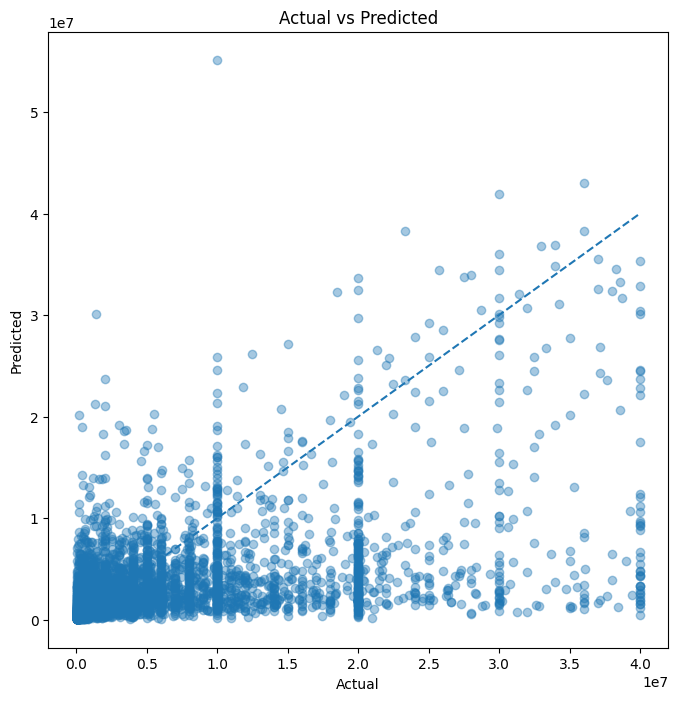

In [87]:
plt.figure(figsize=(8, 8))

plt.scatter(
    error_df["actual"],
    error_df["predicted"],
    alpha=0.4
)

plt.plot(
    [0, error_df["actual"].max()],
    [0, error_df["actual"].max()],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

## 📊 Key observations

### 1. Actual vs Predicted
- Predictions mostly lie **below the diagonal**
- Indicates **underestimation bias**
- Effect is stronger for higher true values

### 2. Structure at low values
- Visible “columns” at small integer values (e.g. 1, 2, 3, 4)
- Reflects **discrete or clustered target behavior**
- Model handles low-value segmentation reasonably well

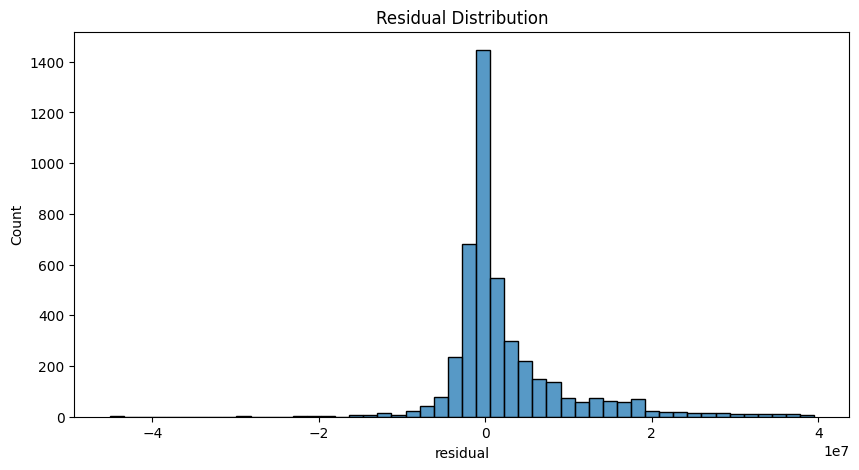

In [88]:
plt.figure(figsize=(10, 5))

sns.histplot(
    error_df["residual"],
    bins=50
)

plt.title("Residual Distribution")

plt.show()

### 3. Residual distribution
- Roughly symmetric overall
- Slight **right skew**
- Confirms systematic **underprediction at the high end**

---

## 🧠 Interpretation

- Strong generalization on typical customers  
- Weak sensitivity to extreme high-value cases  
- Likely due to:
  - sparse feature representation
  - rarity of high-value samples
  - conservative bias of tree-based models

---

## 📌 Implication

The model is reliable for average prediction tasks but needs improvement in:
- high-value customer detection
- tail behavior modeling
- extreme value sensitivity (important for business impact)

---

## 🚀 Next optimization focus
- Improve tail learning (high-value customers)
- Explore reweighting or targeted feature engineering
- Analyze SHAP separately for high vs low value segments